In [34]:
# True Cluster Point Selection Testing
# Author: Prabhjot Singh (prabhjot@fnal.gov)
# Purpose: Test true cluster point selection with min_points cutoff
# This notebook loads a single event and tests selection before/after applying cutoffs

In [35]:
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path
import sys
import os

np.set_printoptions(linewidth=1000)

In [36]:
# Configuration for single event testing
SBNDCODE_VERSION          = "v10_06_00"
PROCESS                   = "nu_spill"
apa                       = "apa0"
evt                       = 3             # Single event for testing
min_cluster_energy        = 5            # in MeV
min_points_threshold      = 200           # Minimum number of points in a cluster

# Directories
OUTDIR=Path("/exp/sbnd/data/users/prabhjot/wirecell_clustering/cluster_evaluation/out/")
SUBDIR="24308437_0"
OUTDIR=OUTDIR / SUBDIR

if PROCESS == "nu_spill":
  OUTDIR = OUTDIR / SBNDCODE_VERSION / PROCESS    
elif PROCESS == "cosmics":
  OUTDIR = OUTDIR / SBNDCODE_VERSION / "cosmics"

NEWOUTDIR     = OUTDIR/"xyz-coordinates"

print(f"Testing event: {evt}")
print(f"Energy cutoff: {min_cluster_energy} MeV")
print(f"Min points threshold: {min_points_threshold}")

Testing event: 3
Energy cutoff: 5 MeV
Min points threshold: 200


In [37]:
def read_true_coordinates(files):
    """Reads coordinates from text files and returns numpy arrays."""
    _x = np.loadtxt(files[0])
    _y = np.loadtxt(files[1])
    _z = np.loadtxt(files[2])
    _id = np.loadtxt(files[3])
    _q = np.loadtxt(files[4])
    _e = np.loadtxt(files[5])
    _t = np.loadtxt(files[6])
    return _x, _y, _z, _id, _q, _e, _t

In [38]:
# Load true coordinates for the event
fx_true = NEWOUTDIR / str(evt) / f"x_truth_{apa}.txt"
fy_true = NEWOUTDIR / str(evt) / f"y_truth_{apa}.txt"
fz_true = NEWOUTDIR / str(evt) / f"z_truth_{apa}.txt"
fid_true = NEWOUTDIR / str(evt) / f"clusterid_truth_{apa}.txt"
fq_true = NEWOUTDIR / str(evt) / f"charge_truth_{apa}.txt"
fe_true = NEWOUTDIR / str(evt) / f"energy_truth_{apa}.txt"
ft_true = NEWOUTDIR / str(evt) / f"time_truth_{apa}.txt"

true_files = [fx_true, fy_true, fz_true, fid_true, fq_true, fe_true, ft_true]
x_true, y_true, z_true, id_true, q_true, e_true, t_true = read_true_coordinates(true_files)

# Combine into single array
true_5d_points = np.column_stack((x_true, y_true, z_true, id_true, q_true, e_true))
print(f"Initial number of true points: {len(true_5d_points)}")

Initial number of true points: 25934


In [39]:
# Function to apply energy cutoff
def apply_energy_cutoff(true_points, energy_cutoff):
    cluster_sums = {}
    for point in true_points:
        cluster_sums[point[3]] = cluster_sums.get(point[3], 0) + point[5]
    
    true_points = np.array([point for point in true_points if cluster_sums[point[3]] >= energy_cutoff])
    return true_points

# Function to apply minimum points cutoff
def apply_min_points_cutoff(true_points, min_points):
    cluster_counts = {}
    for point in true_points:
        cluster_id = point[3]
        cluster_counts[cluster_id] = cluster_counts.get(cluster_id, 0) + 1
    
    true_points = np.array([point for point in true_points if cluster_counts[point[3]] >= min_points])
    return true_points

In [40]:
# Apply energy cutoff
print(f"\nApplying energy cutoff: {min_cluster_energy} MeV")
print(f"Points before energy cutoff: {len(true_5d_points)}")
true_points_after_energy = apply_energy_cutoff(true_5d_points, min_cluster_energy)
print(f"Points after energy cutoff: {len(true_points_after_energy)}")
print(f"Points removed: {len(true_5d_points) - len(true_points_after_energy)}")


Applying energy cutoff: 5 MeV
Points before energy cutoff: 25934
Points after energy cutoff: 25448
Points removed: 486


In [41]:
# Count points per cluster BEFORE min_points cutoff
cluster_counts_before = {}
for point in true_points_after_energy:
    cluster_id = point[3]
    cluster_counts_before[cluster_id] = cluster_counts_before.get(cluster_id, 0) + 1

print(f"\nBEFORE min_points cutoff:")
print(f"Number of clusters: {len(cluster_counts_before)}")
print(f"\nPoints per cluster:")
for cluster_id, count in sorted(cluster_counts_before.items(), key=lambda x: x[1], reverse=True):
    print(f"  Cluster {cluster_id:7.1f}: {count:5d} points")


BEFORE min_points cutoff:
Number of clusters: 10

Points per cluster:
  Cluster    49.0: 10963 points
  Cluster    74.0:  5968 points
  Cluster   110.0:  3446 points
  Cluster    43.0:  1470 points
  Cluster    83.0:  1132 points
  Cluster   181.0:   829 points
  Cluster 461865.0:   740 points
  Cluster   108.0:   696 points
  Cluster 261770.0:   107 points
  Cluster 261496.0:    97 points


In [42]:
# Apply minimum points cutoff
print(f"\nApplying min_points cutoff: {min_points_threshold} points")
# print points and cluster before cutoff
print(f"\nBEFORE min_points cutoff:")
print(f"Number of clusters: {len(cluster_counts_before)}")
print(f"Points before min_points cutoff: {len(true_points_after_energy)}")
true_points_after_minpoints = apply_min_points_cutoff(true_points_after_energy, min_points_threshold)

print ("\n")
print(f"Clusters after min_points cutoff: {len(set(true_points_after_minpoints[:, 3]))}")
print(f"Points after min_points cutoff: {len(true_points_after_minpoints)}")
print ("\n")
print(f"Clustering removed: {len(set(true_points_after_energy[:, 3])) - len(set(true_points_after_minpoints[:, 3]))} clusters")
print(f"Points removed: {len(true_points_after_energy) - len(true_points_after_minpoints)}")



Applying min_points cutoff: 200 points

BEFORE min_points cutoff:
Number of clusters: 10
Points before min_points cutoff: 25448


Clusters after min_points cutoff: 8
Points after min_points cutoff: 25244


Clustering removed: 2 clusters
Points removed: 204


In [43]:
# Count points per cluster AFTER min_points cutoff
cluster_counts_after = {}
for point in true_points_after_minpoints:
    cluster_id = point[3]
    cluster_counts_after[cluster_id] = cluster_counts_after.get(cluster_id, 0) + 1

print(f"\nAFTER min_points cutoff:")
print(f"Number of clusters: {len(cluster_counts_after)}")
print(f"\nPoints per cluster:")
for cluster_id, count in sorted(cluster_counts_after.items(), key=lambda x: x[1], reverse=True):
    print(f"  Cluster {cluster_id:7.1f}: {count:5d} points")


AFTER min_points cutoff:
Number of clusters: 8

Points per cluster:
  Cluster    49.0: 10963 points
  Cluster    74.0:  5968 points
  Cluster   110.0:  3446 points
  Cluster    43.0:  1470 points
  Cluster    83.0:  1132 points
  Cluster   181.0:   829 points
  Cluster 461865.0:   740 points
  Cluster   108.0:   696 points


In [44]:
# Define color map for all clusters (to be used in all visualizations)
colors_all = plt.cm.tab20(np.linspace(0, 1, len(cluster_counts_before)))
sorted_cluster_ids = sorted(cluster_counts_before.keys())
color_map = {cluster_id: colors_all[idx] for idx, cluster_id in enumerate(sorted_cluster_ids)}

print(f"Color map created for {len(color_map)} clusters")

Color map created for 10 clusters


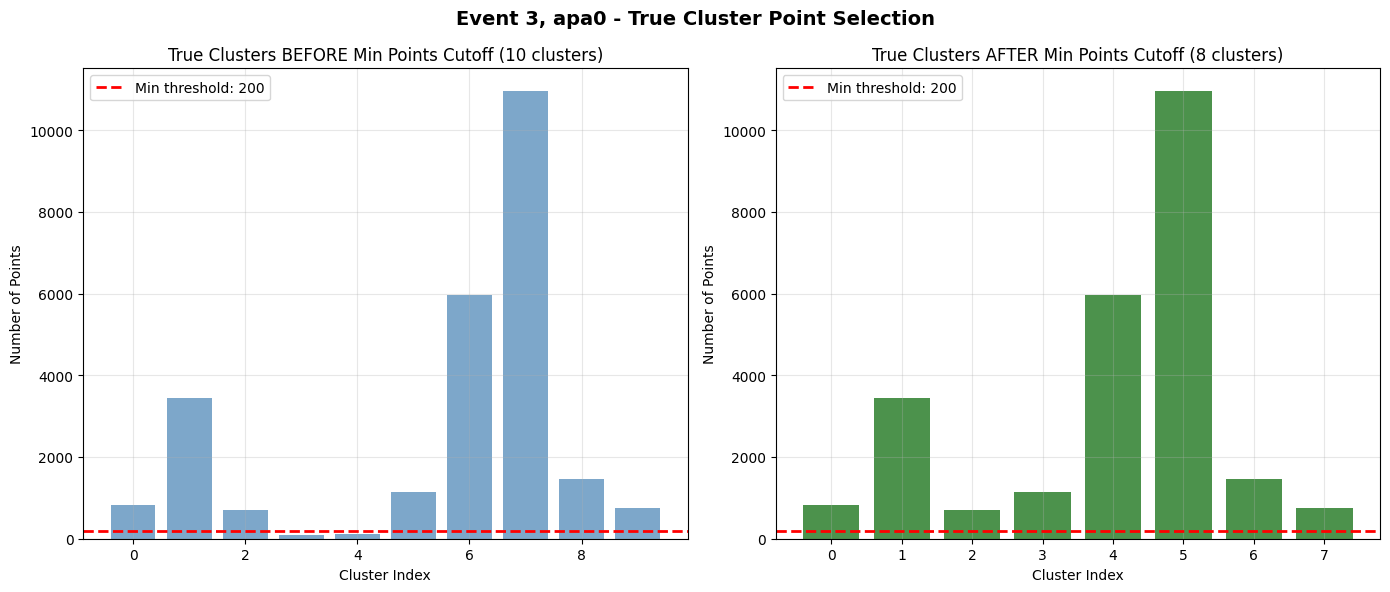


Summary:
  Clusters BEFORE cutoff: 10
  Clusters AFTER cutoff:  8
  Clusters removed: 2


In [45]:
# Create bar plots comparing before and after min_points cutoff
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

# Before cutoff
clusters_before = list(cluster_counts_before.keys())
counts_before = list(cluster_counts_before.values())
axes[0].bar(range(len(clusters_before)), counts_before, color='steelblue', alpha=0.7)
axes[0].axhline(y=min_points_threshold, color='red', linestyle='--', linewidth=2, label=f'Min threshold: {min_points_threshold}')
axes[0].set_xlabel('Cluster Index')
axes[0].set_ylabel('Number of Points')
axes[0].set_title(f'True Clusters BEFORE Min Points Cutoff ({len(clusters_before)} clusters)')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# After cutoff
clusters_after = list(cluster_counts_after.keys())
counts_after = list(cluster_counts_after.values())
axes[1].bar(range(len(clusters_after)), counts_after, color='darkgreen', alpha=0.7)
axes[1].axhline(y=min_points_threshold, color='red', linestyle='--', linewidth=2, label=f'Min threshold: {min_points_threshold}')
axes[1].set_xlabel('Cluster Index')
axes[1].set_ylabel('Number of Points')
axes[1].set_title(f'True Clusters AFTER Min Points Cutoff ({len(clusters_after)} clusters)')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle(f'Event {evt}, {apa} - True Cluster Point Selection', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show(block=False)

print(f"\nSummary:")
print(f"  Clusters BEFORE cutoff: {len(cluster_counts_before)}")
print(f"  Clusters AFTER cutoff:  {len(cluster_counts_after)}")
print(f"  Clusters removed: {len(cluster_counts_before) - len(cluster_counts_after)}")


Example of removed cluster:
  Cluster ID: 261770.0
  Points in cluster: 107 (threshold: 200)
  Status: REMOVED (less than 200 points)


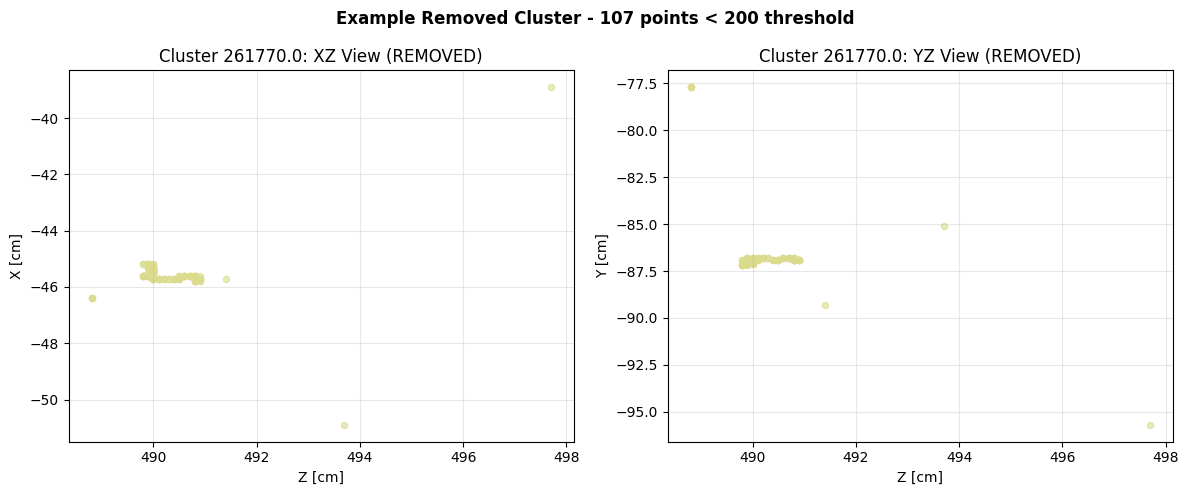


Example of kept cluster:
  Cluster ID: 49.0
  Points in cluster: 10963 (threshold: 200)
  Status: KEPT (>= 200 points)


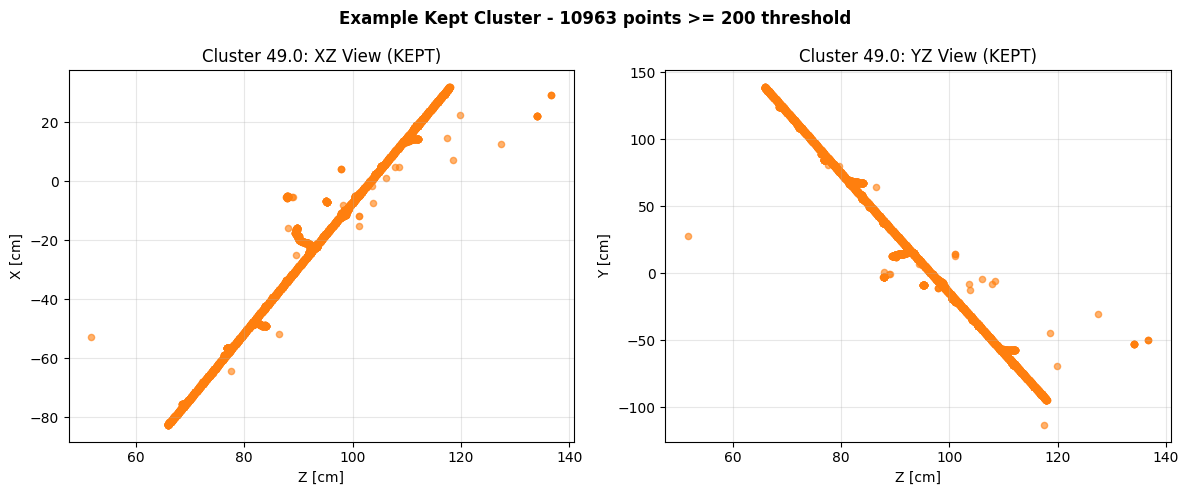

In [46]:
# Show example of a cluster that was removed
removed_clusters = set(cluster_counts_before.keys()) - set(cluster_counts_after.keys())

if removed_clusters:
    # Pick the largest removed cluster for visualization
    largest_removed = max(removed_clusters, key=lambda x: cluster_counts_before[x])
    count_removed = cluster_counts_before[largest_removed]
    color_removed = color_map[largest_removed]
    
    print(f"\nExample of removed cluster:")
    print(f"  Cluster ID: {largest_removed}")
    print(f"  Points in cluster: {count_removed} (threshold: {min_points_threshold})")
    print(f"  Status: REMOVED (less than {min_points_threshold} points)")
    
    # Get points from this cluster
    example_points = true_points_after_energy[true_points_after_energy[:, 3] == largest_removed]
    
    # Plot the example cluster
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # XZ view
    axes[0].scatter(example_points[:, 2], example_points[:, 0], s=20, alpha=0.6, color=color_removed)
    axes[0].set_xlabel('Z [cm]')
    axes[0].set_ylabel('X [cm]')
    axes[0].set_title(f'Cluster {largest_removed}: XZ View (REMOVED)')
    axes[0].grid(True, alpha=0.3)
    
    # YZ view
    axes[1].scatter(example_points[:, 2], example_points[:, 1], s=20, alpha=0.6, color=color_removed)
    axes[1].set_xlabel('Z [cm]')
    axes[1].set_ylabel('Y [cm]')
    axes[1].set_title(f'Cluster {largest_removed}: YZ View (REMOVED)')
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle(f'Example Removed Cluster - {count_removed} points < {min_points_threshold} threshold', fontweight='bold')
    plt.tight_layout()
    plt.show(block=False)
else:
    print("No clusters were removed by the min_points cutoff.")

# Show example of a cluster that was kept
kept_clusters = set(cluster_counts_after.keys())
if kept_clusters:
    largest_kept = max(kept_clusters, key=lambda x: cluster_counts_after[x])
    count_kept = cluster_counts_after[largest_kept]
    color_kept = color_map[largest_kept]
    
    print(f"\nExample of kept cluster:")
    print(f"  Cluster ID: {largest_kept}")
    print(f"  Points in cluster: {count_kept} (threshold: {min_points_threshold})")
    print(f"  Status: KEPT (>= {min_points_threshold} points)")
    
    # Get points from this cluster
    example_points_kept = true_points_after_minpoints[true_points_after_minpoints[:, 3] == largest_kept]
    
    # Plot the example cluster
    fig, axes = plt.subplots(1, 2, figsize=(12, 5))
    
    # XZ view
    axes[0].scatter(example_points_kept[:, 2], example_points_kept[:, 0], s=20, alpha=0.6, color=color_kept)
    axes[0].set_xlabel('Z [cm]')
    axes[0].set_ylabel('X [cm]')
    axes[0].set_title(f'Cluster {largest_kept}: XZ View (KEPT)')
    axes[0].grid(True, alpha=0.3)
    
    # YZ view
    axes[1].scatter(example_points_kept[:, 2], example_points_kept[:, 1], s=20, alpha=0.6, color=color_kept)
    axes[1].set_xlabel('Z [cm]')
    axes[1].set_ylabel('Y [cm]')
    axes[1].set_title(f'Cluster {largest_kept}: YZ View (KEPT)')
    axes[1].grid(True, alpha=0.3)
    
    plt.suptitle(f'Example Kept Cluster - {count_kept} points >= {min_points_threshold} threshold', fontweight='bold')
    plt.tight_layout()
    plt.show(block=False)

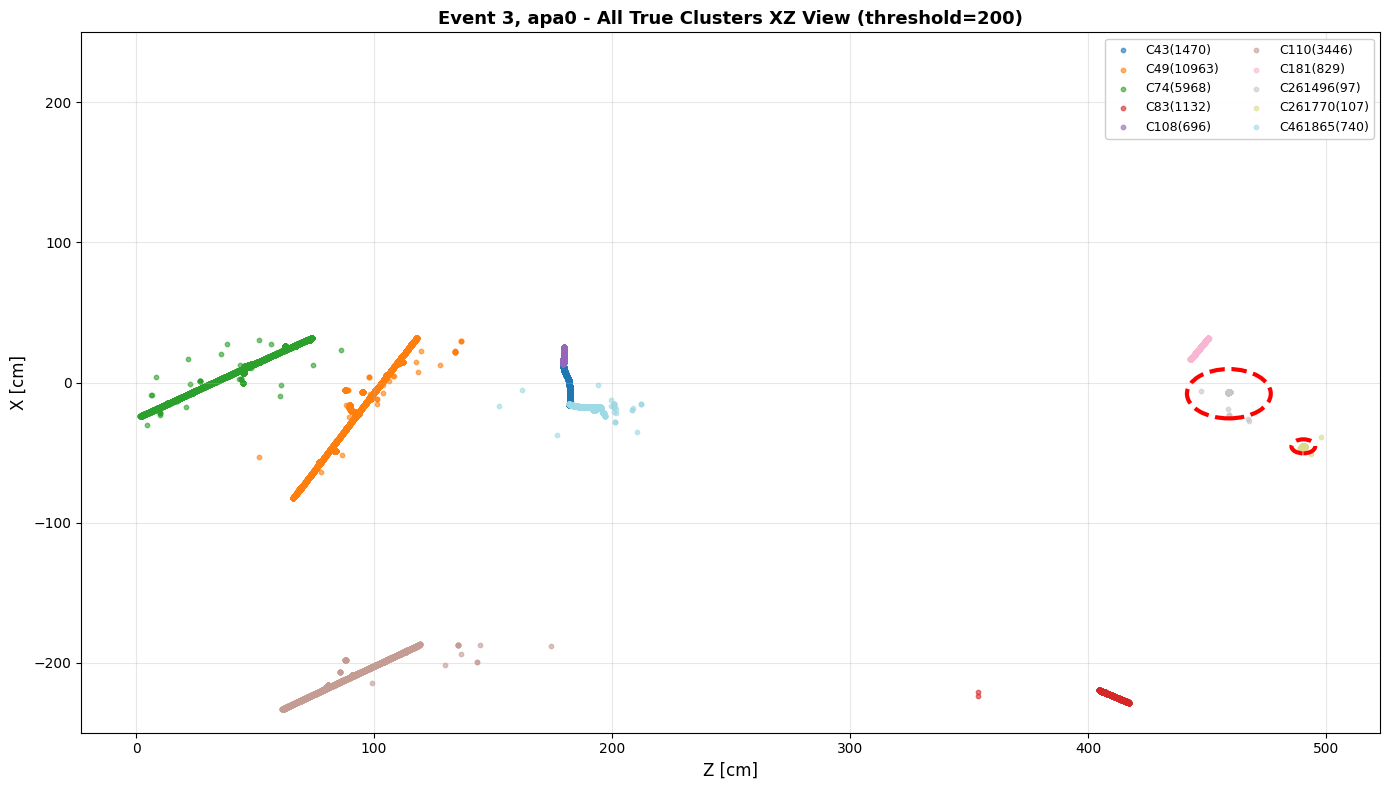


XZ View Summary:
Total clusters: 10
Removed clusters (with red circle highlight): 2
  - Cluster 261496: 97 points
  - Cluster 261770: 107 points
Kept clusters: 8


In [47]:
# Draw ALL clusters in XZ view with circle highlighting removed clusters
from matplotlib.patches import Circle

# Group clusters
def group_clusters_by_id(points):
    clusters = {}
    for point in points:
        cluster_id = point[3]
        if cluster_id not in clusters:
            clusters[cluster_id] = []
        clusters[cluster_id].append(point)
    return clusters

clusters_before = group_clusters_by_id(true_points_after_energy)
clusters_after = group_clusters_by_id(true_points_after_minpoints)

# Find removed clusters
removed_clusters = set(clusters_before.keys()) - set(clusters_after.keys())

# Create figure
fig, ax = plt.subplots(figsize=(14, 8))

# Define colors for each cluster (consistent across all visualizations)
colors_all = plt.cm.tab20(np.linspace(0, 1, len(clusters_before)))

# Draw all clusters with original colors
for idx, (cluster_id, points) in enumerate(sorted(clusters_before.items())):
    points_arr = np.array(points)
    count = len(points_arr)
    
    # Use original color for all clusters
    ax.scatter(points_arr[:, 2], points_arr[:, 0], s=10, alpha=0.6, 
              label=f'C{cluster_id:.0f}({count})', color=colors_all[idx])
    
    # Add circle around removed clusters only (without changing color)
    if cluster_id in removed_clusters:
        z_center = np.mean(points_arr[:, 2])
        x_center = np.mean(points_arr[:, 0])
        z_std = np.std(points_arr[:, 2])
        x_std = np.std(points_arr[:, 0])
        radius = np.sqrt(z_std**2 + x_std**2) * 4  # Circle (2x larger)
        
        circle = Circle((z_center, x_center), radius, fill=False, edgecolor='red', 
                       linewidth=3, linestyle='--')
        ax.add_patch(circle)

ax.set_xlabel('Z [cm]', fontsize=12)
ax.set_ylabel('X [cm]', fontsize=12)
ax.set_title(f'Event {evt}, {apa} - All True Clusters XZ View (threshold={min_points_threshold})', 
            fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, ncol=2, framealpha=0.95)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.ylim(-250, 250)
plt.show(block=False)

print(f"\nXZ View Summary:")
print(f"Total clusters: {len(clusters_before)}")
print(f"Removed clusters (with red circle highlight): {len(removed_clusters)}")
if removed_clusters:
    for cluster_id in removed_clusters:
        print(f"  - Cluster {cluster_id:.0f}: {len(clusters_before[cluster_id])} points")
print(f"Kept clusters: {len(clusters_after)}")

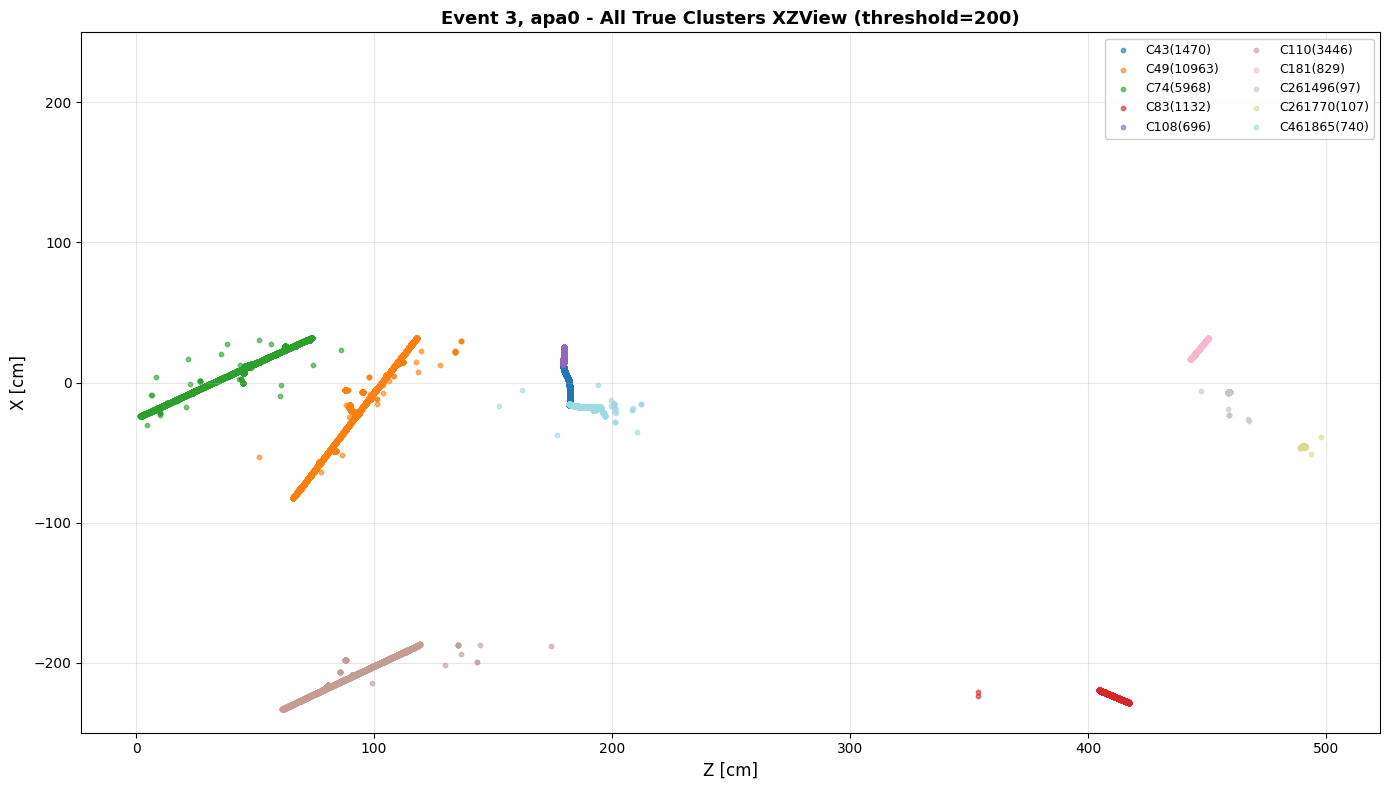

In [48]:
# Also save same above copy but without circles
fig, ax = plt.subplots(figsize=(14, 8))
for idx, (cluster_id, points) in enumerate(sorted(clusters_before.items())):
    points_arr = np.array(points)
    count = len(points_arr)
    
    # Use original color for all clusters
    ax.scatter(points_arr[:, 2], points_arr[:, 0], s=10, alpha=0.6, 
              label=f'C{cluster_id:.0f}({count})', color=colors_all[idx])
ax.set_xlabel('Z [cm]', fontsize=12)
ax.set_ylabel('X [cm]', fontsize=12)
ax.set_title(f'Event {evt}, {apa} - All True Clusters XZView (threshold={min_points_threshold})', 
              fontsize=13, fontweight='bold')
ax.legend(loc='upper right', fontsize=9, ncol=2, framealpha=0.95)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.ylim(-250, 250)
plt.show(block=False)


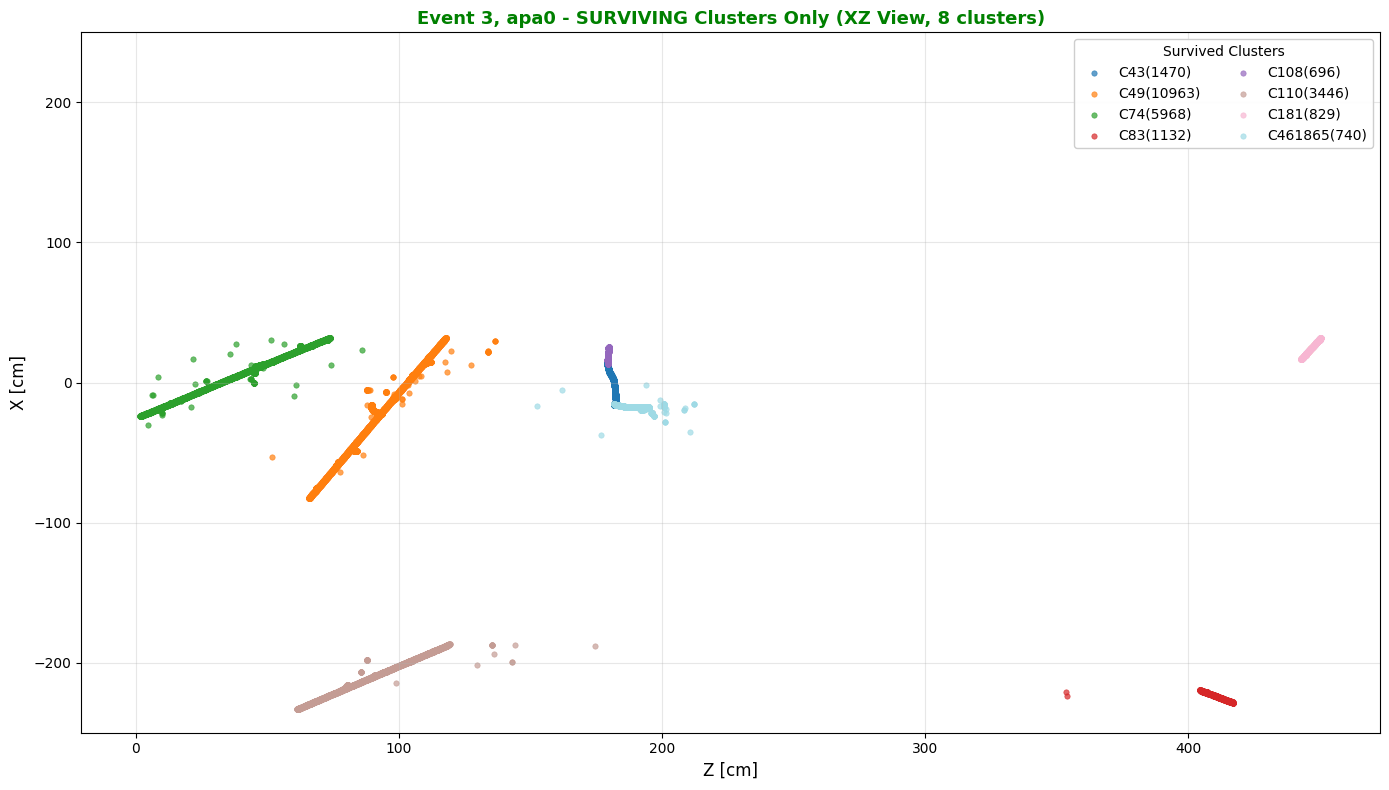


Surviving Clusters Summary:
Total surviving clusters: 8
Total surviving points: 25244

Surviving cluster details:
  - Cluster    43.0:  1470 points
  - Cluster    49.0: 10963 points
  - Cluster    74.0:  5968 points
  - Cluster    83.0:  1132 points
  - Cluster   108.0:   696 points
  - Cluster   110.0:  3446 points
  - Cluster   181.0:   829 points
  - Cluster 461865.0:   740 points


In [49]:
# Draw only SURVIVING clusters (after min_points cutoff) in single display
fig, ax = plt.subplots(figsize=(14, 8))

# Draw only surviving clusters using color_map
for cluster_id in sorted(clusters_after.keys()):
    points = clusters_after[cluster_id]
    points_arr = np.array(points)
    count = len(points_arr)
    color = color_map[cluster_id]  # Use color from global color_map
    
    ax.scatter(points_arr[:, 2], points_arr[:, 0], s=15, alpha=0.7, 
              label=f'C{cluster_id:.0f}({count})', color=color, linewidth=0.5)

ax.set_xlabel('Z [cm]', fontsize=12)
ax.set_ylabel('X [cm]', fontsize=12)
ax.set_title(f'Event {evt}, {apa} - SURVIVING Clusters Only (XZ View, {len(clusters_after)} clusters)', 
            fontsize=13, fontweight='bold', color='green')
ax.legend(loc='upper right', fontsize=10, ncol=2, framealpha=0.95, title='Survived Clusters')
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.ylim(-250, 250)
plt.show(block=False)

print(f"\nSurviving Clusters Summary:")
print(f"Total surviving clusters: {len(clusters_after)}")
print(f"Total surviving points: {len(true_points_after_minpoints)}")
print(f"\nSurviving cluster details:")
for cluster_id in sorted(clusters_after.keys()):
    count = len(clusters_after[cluster_id])
    print(f"  - Cluster {cluster_id:7.1f}: {count:5d} points")